# Polynomial Regression — Google Colab

**Goal:** Model **non-linear** relationships by adding polynomial features (x, x², x³, …) and fitting Linear Regression on the expanded feature space.

| Example | Feature (X) | Target (y) | Degree | Dataset |
|---------|-------------|------------|--------|---------|
| **Example 1** | X_value | Target | **9** (overfitting demo) | `../Datasets/overfitting_poly.csv` |
| **Example 2** | Temperature_C | Sales_units | 2 | `../Datasets/ice_cream_sales.csv` |

| Phase | Topic | Cells |
|-------|-------|-------|
| Phase 0 | Setup | Install & Imports |
| Phase 1 | Data Pre-processing | Load → Cleaning → Split |
| Phase 2 | Algorithm | Linear vs Polynomial → Train → Coefficient Matrix → Predict → Visualize → Evaluate |

> **Run:** Runtime → Run all (or Ctrl+F9)


## Phase 0 — Cell 0: Install Libraries

Google Colab usually includes most libraries. This cell ensures required packages are available.

**What this cell does:** Installs scikit-learn, pandas, matplotlib, and numpy quietly.


In [138]:
# Install into the same Python as this notebook kernel (avoids pip/kernel mismatch)
import sys
!{sys.executable} -m pip install -q scikit-learn pandas matplotlib numpy



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python3.11 -m pip install --upgrade pip


## Phase 0 — Cell 1: Import Libraries

Import libraries for data handling, polynomial feature engineering, modeling, and evaluation.

**What this cell does:** Loads numpy, pandas, matplotlib, sklearn modules, and Pipeline helpers.


In [139]:
# --- Import libraries ---
import numpy as np              # Numerical operations and arrays
import pandas as pd             # Load and manipulate tabular data
import matplotlib.pyplot as plt # Create charts and plots
from IPython.display import display  # Pretty-print DataFrames in notebook output

from sklearn.model_selection import train_test_split  # Split data into train/test
from sklearn.impute import SimpleImputer              # Fill missing values
from sklearn.preprocessing import PolynomialFeatures  # Create x, x², x³, ... features
from sklearn.pipeline import Pipeline                 # Chain preprocessing + model
from sklearn.linear_model import LinearRegression     # Linear model on expanded features
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Evaluation metrics

plt.rcParams['figure.figsize'] = (10, 6)  # Default plot size: width=10, height=6 inches
plt.style.use('seaborn-v0_8-whitegrid')   # Clean white background with grid lines
np.random.seed(42)                          # Fix random seed for reproducible splits

print('Libraries ready')                      # Confirm all imports loaded successfully


Libraries ready


---
# Example 1: Overfitting Demo — Polynomial Regression

Predict **Target** from **X_value**. The **true** pattern is roughly **linear**, but random **noise** was added. With **degree 9** on only **14 rows**, the model **memorizes noise** → classic **overfitting**.`.

| Column | Role | Description |
|--------|------|-------------|
| `X_value` | Feature (X) | Input value (1–14) |
| `Target` | Target (y) | Noisy output (linear trend + noise) |

**File:** `../Datasets/overfitting_poly.csv`


---
# Phase 1: Data Pre-processing

Prepare the data before training the model — same template is reused for other algorithms.


## Example 1 — Cell 1: Load and Explore Data

Load the CSV file and perform initial exploration (head, info, describe, shape).

**What this cell does:** Reads `../Datasets/overfitting_poly.csv` and displays basic statistics.


In [140]:
# Step 1) Load dataset
dataset = pd.read_csv('../Datasets/overfitting_poly.csv')  # Noisy data — built for overfitting demo

FEATURE_COL = 'X_value'   # Independent variable (numeric)
TARGET_COL = 'Target'   # Dependent variable (noisy)
POLY_DEG = 9               # High degree on 14 rows → strong overfitting

print('First 5 rows:')
display(dataset.head())
print(f'\nShape: {dataset.shape[0]} rows x {dataset.shape[1]} columns')
print('\nSummary statistics:')
display(dataset.describe().round(2))


First 5 rows:


,X_value,Target
0,1.0,34.0
1,2.0,34.3
2,3.0,51.8
3,4.0,70.3
4,5.0,57.2



Shape: 14 rows x 2 columns

Summary statistics:


,X_value,Target
count,14.00,14.00
mean,7.50,81.61
std,4.18,29.62
min,1.00,34.00
25%,4.25,59.20
50%,7.50,89.80
75%,10.75,105.48
max,14.00,126.90


## Example 1 — Cell 2: Data Cleaning (Handling Missing Values)

Check for missing values and impute if needed.

**What this cell does:** Reports missing values and fills numeric gaps with the column mean.


In [141]:
# Step 2) Data cleaning
print('Missing values per column:')
print(dataset.isnull().sum())

if dataset[[FEATURE_COL, TARGET_COL]].isnull().any().any():
    imputer = SimpleImputer(strategy='mean')
    dataset[[FEATURE_COL, TARGET_COL]] = imputer.fit_transform(dataset[[FEATURE_COL, TARGET_COL]])
    print('\nMissing values filled with column mean.')
else:
    print('\nNo missing values — cleaning skipped.')


Missing values per column:
X_value    0
Target     0
dtype: int64

No missing values — cleaning skipped.


## Example 1 — Cell 3: Feature Matrix

Single numeric feature — no categorical encoding needed.

**What this cell does:** Builds X (Level) and y (Salary) for modeling.


In [142]:
# Step 3) Feature matrix
X = dataset[[FEATURE_COL]].copy()  # Feature as 2D DataFrame (required by sklearn)
y = dataset[TARGET_COL].values       # Target as 1D array

print(f'Feature: {FEATURE_COL}')
print(f'Target:  {TARGET_COL}')
print(f'Polynomial degree: {POLY_DEG}')


Feature: X_value
Target:  Target
Polynomial degree: 9


## Example 1 — Cell 4: Splitting the Data

Define feature matrix X and target y, then split into 80% training and 20% test sets.

**What this cell does:** Creates feature/target arrays and applies train_test_split.


In [143]:
# Step 4) Train-Test split
X_values = X.values
y_values = y

X_train, X_test, y_train, y_test = train_test_split(
    X_values, y_values,
    test_size=0.2,
    random_state=42
)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape:  {y_test.shape}')


X_train shape: (11, 1)
X_test shape:  (3, 1)
y_train shape: (11,)
y_test shape:  (3,)


> **Note:** Example 1 uses **degree 9** on **14 noisy rows** — Train R² ≈ 1.0 but Test R² collapses. Example 2 uses degree 2 (healthy fit).


---
# Phase 2: Polynomial Regression

Compare **Simple Linear** vs **Polynomial** fit, then train the polynomial model.


## Example 1 — Cell 5: Train the Model

Train a **LinearRegression** baseline and a **Polynomial** pipeline (`PolynomialFeatures` → `LinearRegression`).

**What this cell does:** Fits both models and prints R² on train/test for comparison.


In [144]:
# Step 5) Train models — Linear vs Polynomial
POLY_DEG = 9  # High degree → overfitting (Train R² ≈ 1.0 on small data)
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=POLY_DEG, include_bias=False)),
    ('model', LinearRegression())
])
poly_model.fit(X_train, y_train)

regressor = poly_model  # Use polynomial model as main regressor

train_r2 = poly_model.score(X_train, y_train)
test_r2 = poly_model.score(X_test, y_test)

print('Model comparison (R²):')
print(f'  Linear     — Train: {linear_model.score(X_train, y_train):.4f}, Test: {linear_model.score(X_test, y_test):.4f}')
print(f'  Polynomial — Train: {train_r2:.4f}, Test: {test_r2:.4f}')

if train_r2 >= 0.999 and train_r2 - test_r2 > 0.02:
    print('\n⚠️  Overfitting detected: Train R² ≈ 1.0 and higher than Test R²')
elif train_r2 >= 0.999:
    print('\n⚠️  Overfitting: Train R² = 1.0 — model memorized every training point')

poly_names = poly_model.named_steps['poly'].get_feature_names_out([FEATURE_COL])
coefs = poly_model.named_steps['model'].coef_
print(f'\nPolynomial coefficients ({POLY_DEG} terms):')
for name, c in zip(poly_names, coefs):
    print(f'  {name}: {c:.4f}')
print(f'Intercept (b0): {poly_model.named_steps["model"].intercept_:.2f}')


Model comparison (R²):
  Linear     — Train: 0.8619, Test: 0.9704
  Polynomial — Train: 0.9965, Test: -352.7175

Polynomial coefficients (9 terms):
  X_value: -14350.4639
  X_value^2: 9912.4369
  X_value^3: -3730.0509
  X_value^4: 849.0366
  X_value^5: -122.0581
  X_value^6: 11.1526
  X_value^7: -0.6281
  X_value^8: 0.0199
  X_value^9: -0.0003
Intercept (b0): 8608.86


## Example 1 — Cell 5b: Coefficient Matrix

Visualize the learned polynomial weights as a **coefficient matrix** (β): heatmap + bar chart.

**What this cell does:** Draws the β matrix for all polynomial terms.


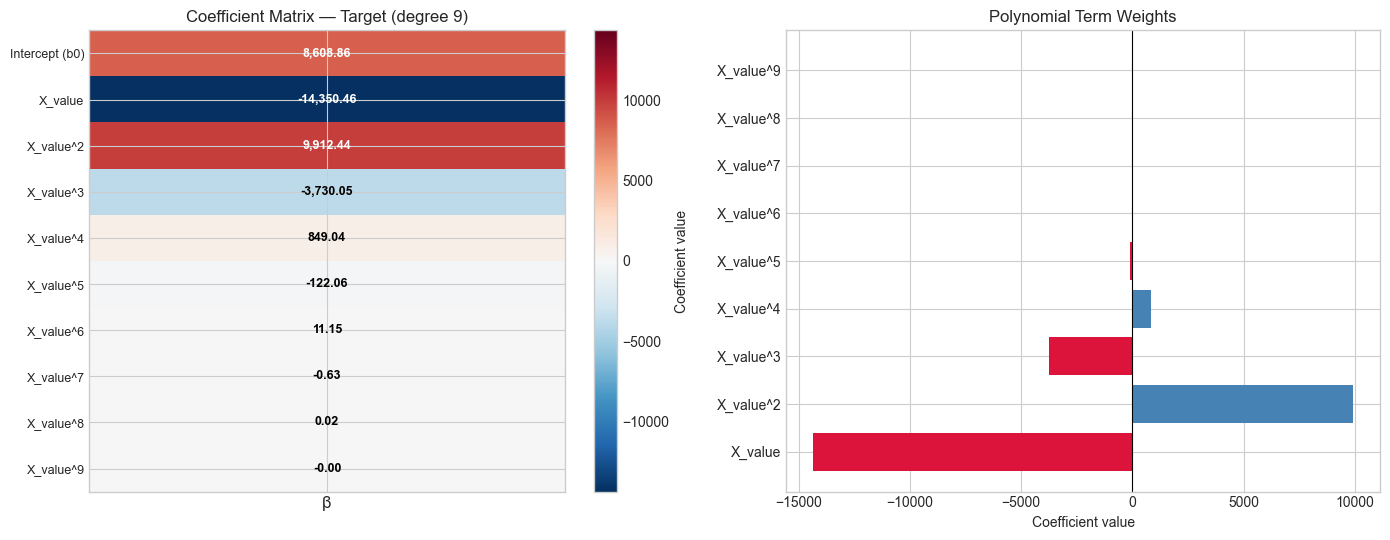

In [145]:
# Step 5b) Coefficient Matrix — visual plot
poly_names = poly_model.named_steps['poly'].get_feature_names_out([FEATURE_COL])
coefficients = np.concatenate([[poly_model.named_steps['model'].intercept_], poly_model.named_steps['model'].coef_])
features = ['Intercept (b0)'] + list(poly_names)
beta_matrix = coefficients.reshape(-1, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, max(5, 0.55 * len(features))))

ax0 = axes[0]
vmax = np.max(np.abs(coefficients)) or 1
im = ax0.imshow(beta_matrix, cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)
ax0.set_xticks([0])
ax0.set_xticklabels(['β'], fontsize=12)
ax0.set_yticks(range(len(features)))
ax0.set_yticklabels(features, fontsize=9)
for i, val in enumerate(coefficients):
    text_color = 'white' if abs(val) > 0.45 * vmax else 'black'
    ax0.text(0, i, f'{val:,.2f}', ha='center', va='center', fontsize=9, fontweight='bold', color=text_color)
ax0.set_title(f'Coefficient Matrix — {TARGET_COL} (degree {POLY_DEG})')
plt.colorbar(im, ax=ax0, label='Coefficient value')

ax1 = axes[1]
colors = ['steelblue' if c >= 0 else 'crimson' for c in poly_model.named_steps['model'].coef_]
ax1.barh(list(poly_names), poly_model.named_steps['model'].coef_, color=colors)
ax1.axvline(0, color='black', linewidth=0.8)
ax1.set_xlabel('Coefficient value')
ax1.set_title('Polynomial Term Weights')

plt.tight_layout()
plt.show()


## Example 1 — Cell 6: Predict

Generate predictions on training and test sets.

**What this cell does:** Creates y_pred_train and y_pred_test using the fitted polynomial model.


In [146]:
# Step 6) Predict
y_pred_train = regressor.predict(X_train)
y_pred_test = regressor.predict(X_test)

print('Sample predictions (Test set):')
for i in range(min(5, len(y_test))):
    print(f'  Actual {TARGET_COL}={y_test[i]:,.0f}, Predicted={y_pred_test[i]:,.0f}')


Sample predictions (Test set):
  Actual Target=106, Predicted=89
  Actual Target=110, Predicted=109
  Actual Target=34, Predicted=1,178


## Example 1 — Cell 7: Visualization

Scatter plot of data with **linear** and **polynomial** fit curves.

**What this cell does:** Shows why a straight line fails and the polynomial curve fits better.


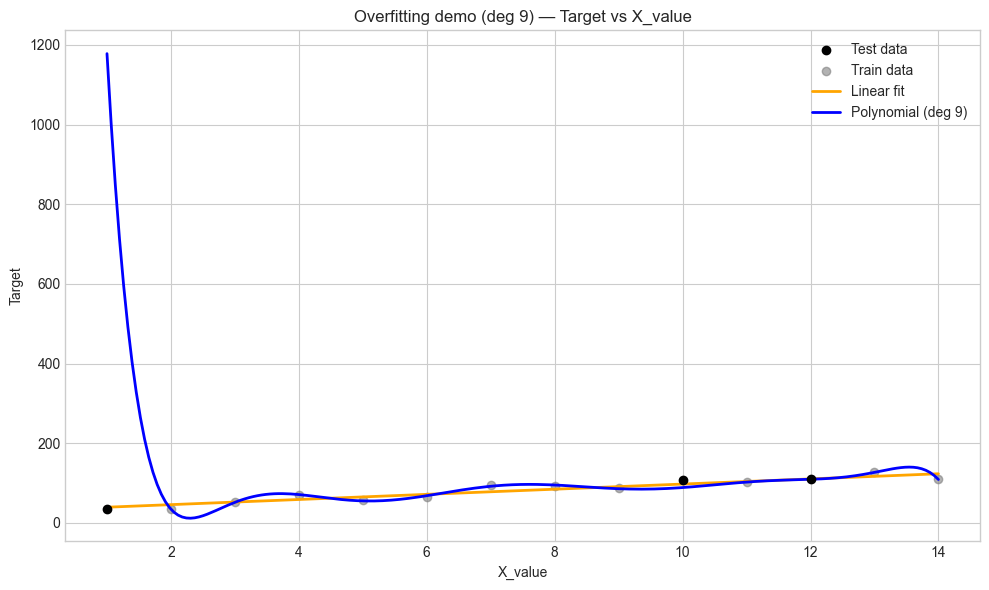

In [147]:
# Step 7) Visualization — Linear vs Polynomial curve
X_plot = np.linspace(X_values.min(), X_values.max(), 200).reshape(-1, 1)

plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='black', label='Test data', zorder=3)
plt.scatter(X_train, y_train, color='gray', alpha=0.6, label='Train data', zorder=2)
plt.plot(X_plot, linear_model.predict(X_plot), color='orange', linewidth=2, label='Linear fit')
plt.plot(X_plot, poly_model.predict(X_plot), color='blue', linewidth=2, label=f'Polynomial (deg {POLY_DEG})')
plt.xlabel(FEATURE_COL)
plt.ylabel(TARGET_COL)
plt.title(f'Overfitting demo (deg {POLY_DEG}) — {TARGET_COL} vs {FEATURE_COL}')
plt.legend()
plt.tight_layout()
plt.show()


## Example 1 — Cell 8: Evaluation

Evaluate the polynomial model with MAE, RMSE, and R².

**What this cell does:** Computes and displays regression evaluation metrics.


In [148]:
# Step 8) Evaluation
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2 = r2_score(y_test, y_pred_test)

results = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R²'],
    'Value': [mae, rmse, r2],
    'Description': [
        'Mean Absolute Error (USD)',
        'Root Mean Squared Error (USD)',
        'Coefficient of Determination (1 = perfect)'
    ]
})

display(results.round(4))
print(f'\nExample 1 Test R² = {r2:.4f}')


,Metric,Value,Description
0,MAE,387.6922,Mean Absolute Error (USD)
1,RMSE,660.7439,Root Mean Squared Error (USD)
2,R²,-352.7175,Coefficient of Determination (1 = perfect)



Example 1 Test R² = -352.7175


## Why does Example 1 Overfit?

| # | Signal | What you see |
|---|--------|--------------|
| 1 | **Train R² ≈ 1.0** | Polynomial passes through every training point |
| 2 | **Test R² very low / negative** | Model fails on unseen data |
| 3 | **Wiggly curve** | Degree 9 bends to fit noise, not true trend |
| 4 | **Fix** | Lower degree (2–3), more data, or **Regularization** |


---
# Example 2: Ice Cream Sales — Polynomial Regression

Predict **Sales_units** from **Temperature_C**. Sales rise then level off (quadratic curve).

| Column | Role | Description |
|--------|------|-------------|
| `Temperature_C` | Feature (X) | Daily temperature in °C |
| `Sales_units` | Target (y) | Ice cream units sold |

**File:** `../Datasets/ice_cream_sales.csv`


## Example 2 — Cell 1: Load and Explore Data

Load the ice cream sales CSV and inspect the data.

**What this cell does:** Reads `../Datasets/ice_cream_sales.csv` and displays basic statistics.


In [149]:
# Load ice cream sales dataset
dataset = pd.read_csv('../Datasets/ice_cream_sales.csv')

FEATURE_COL = 'Temperature_C'
TARGET_COL = 'Sales_units'
POLY_DEG = 2

print('First 5 rows:')
display(dataset.head())
print(f'\nShape: {dataset.shape[0]} rows x {dataset.shape[1]} columns')
display(dataset.describe().round(2))


First 5 rows:


,Temperature_C,Sales_units
0,18.0,641
1,18.5,632
2,18.9,670
3,19.4,712
4,19.8,658



Shape: 45 rows x 2 columns


,Temperature_C,Sales_units
count,45.00,45.00
mean,28.00,493.84
std,5.97,209.04
min,18.00,120.00
25%,23.00,345.00
50%,28.00,593.00
75%,33.00,667.00
max,38.00,736.00


## Example 2 — Cell 2: Data Cleaning (Handling Missing Values)

Check for missing values and impute if needed.

**What this cell does:** Reports and handles missing data.


In [150]:
# Data cleaning
print('Missing values per column:')
print(dataset.isnull().sum())

if dataset[[FEATURE_COL, TARGET_COL]].isnull().any().any():
    imputer = SimpleImputer(strategy='mean')
    dataset[[FEATURE_COL, TARGET_COL]] = imputer.fit_transform(dataset[[FEATURE_COL, TARGET_COL]])
    print('\nMissing values filled with column mean.')
else:
    print('\nNo missing values — cleaning skipped.')


Missing values per column:
Temperature_C    0
Sales_units      0
dtype: int64

No missing values — cleaning skipped.


## Example 2 — Cell 3: Feature Matrix

Build X and y from the single numeric feature.

**What this cell does:** Prepares feature and target arrays.


In [151]:
# Feature matrix
X = dataset[[FEATURE_COL]].copy()
y = dataset[TARGET_COL].values

print(f'Feature: {FEATURE_COL}')
print(f'Target:  {TARGET_COL}')
print(f'Polynomial degree: {POLY_DEG}')


Feature: Temperature_C
Target:  Sales_units
Polynomial degree: 2


## Example 2 — Cell 4: Splitting the Data

Split into 80% train and 20% test.

**What this cell does:** Applies train_test_split.


In [152]:
# Train-Test split
X_values = X.values
y_values = y

X_train, X_test, y_train, y_test = train_test_split(
    X_values, y_values,
    test_size=0.2,
    random_state=42
)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')


X_train shape: (36, 1)
X_test shape:  (9, 1)


## Example 2 — Cell 5: Train the Model

Train linear baseline and polynomial model (degree 2).

**What this cell does:** Fits both models and compares R².


In [153]:
# Train models
POLY_DEG = 2  # Must be int (2, 3, ...) — do NOT use mean/median of X
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=POLY_DEG, include_bias=False)),
    ('model', LinearRegression())
])
poly_model.fit(X_train, y_train)
regressor = poly_model

print('Model comparison (R²):')
print(f'  Linear     — Train: {linear_model.score(X_train, y_train):.4f}, Test: {linear_model.score(X_test, y_test):.4f}')
print(f'  Polynomial — Train: {poly_model.score(X_train, y_train):.4f}, Test: {poly_model.score(X_test, y_test):.4f}')

poly_names = poly_model.named_steps['poly'].get_feature_names_out([FEATURE_COL])
for name, c in zip(poly_names, poly_model.named_steps['model'].coef_):
    print(f'  {name}: {c:.4f}')
print(f'Intercept (b0): {poly_model.named_steps["model"].intercept_:.2f}')


Model comparison (R²):
  Linear     — Train: 0.8184, Test: 0.8748
  Polynomial — Train: 0.9580, Test: 0.9779
  Temperature_C: 99.0475
  Temperature_C^2: -2.3441
Intercept (b0): -358.96


## Example 2 — Cell 5b: Coefficient Matrix

Visualize polynomial coefficients as a heatmap + bar chart.

**What this cell does:** Draws the β matrix for Temperature and Temperature² terms.


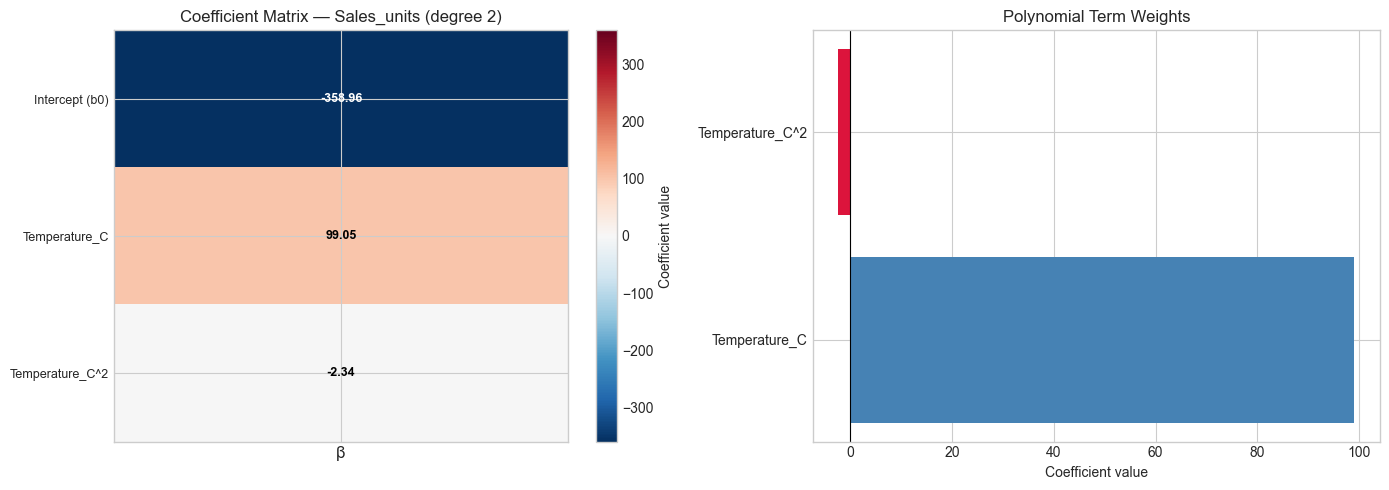

In [154]:
# Coefficient Matrix — visual plot
poly_names = poly_model.named_steps['poly'].get_feature_names_out([FEATURE_COL])
coefficients = np.concatenate([[poly_model.named_steps['model'].intercept_], poly_model.named_steps['model'].coef_])
features = ['Intercept (b0)'] + list(poly_names)
beta_matrix = coefficients.reshape(-1, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, max(5, 0.55 * len(features))))

ax0 = axes[0]
vmax = np.max(np.abs(coefficients)) or 1
im = ax0.imshow(beta_matrix, cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)
ax0.set_xticks([0])
ax0.set_xticklabels(['β'], fontsize=12)
ax0.set_yticks(range(len(features)))
ax0.set_yticklabels(features, fontsize=9)
for i, val in enumerate(coefficients):
    text_color = 'white' if abs(val) > 0.45 * vmax else 'black'
    ax0.text(0, i, f'{val:,.2f}', ha='center', va='center', fontsize=9, fontweight='bold', color=text_color)
ax0.set_title(f'Coefficient Matrix — {TARGET_COL} (degree {POLY_DEG})')
plt.colorbar(im, ax=ax0, label='Coefficient value')

ax1 = axes[1]
colors = ['steelblue' if c >= 0 else 'crimson' for c in poly_model.named_steps['model'].coef_]
ax1.barh(list(poly_names), poly_model.named_steps['model'].coef_, color=colors)
ax1.axvline(0, color='black', linewidth=0.8)
ax1.set_xlabel('Coefficient value')
ax1.set_title('Polynomial Term Weights')

plt.tight_layout()
plt.show()


## Example 2 — Cell 6: Predict

Predict sales for test samples.

**What this cell does:** Generates predictions and shows sample comparisons.


In [155]:
# Predict
y_pred_train = regressor.predict(X_train)
y_pred_test = regressor.predict(X_test)

print('Sample predictions (Test set):')
for i in range(min(5, len(y_test))):
    print(f'  Actual {TARGET_COL}={y_test[i]:,.0f}, Predicted={y_pred_test[i]:,.0f}')


Sample predictions (Test set):
  Actual Sales_units=155, Predicted=189
  Actual Sales_units=551, Predicted=527
  Actual Sales_units=489, Predicted=511
  Actual Sales_units=120, Predicted=59
  Actual Sales_units=245, Predicted=305


## Example 2 — Cell 7: Visualization

Plot data points with linear vs polynomial curves.

**What this cell does:** Shows the curved relationship between temperature and sales.


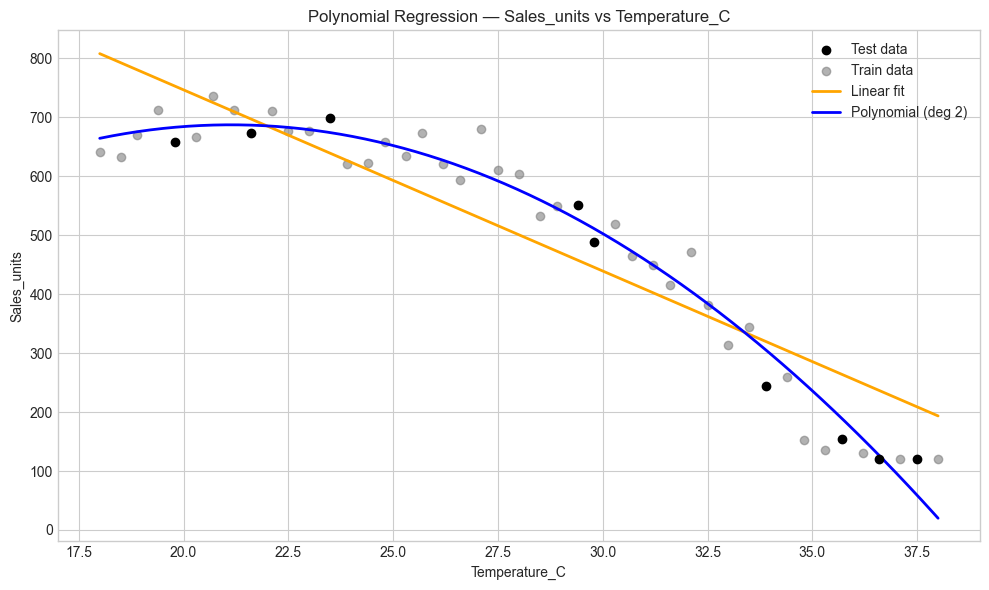

In [156]:
# Visualization
X_plot = np.linspace(X_values.min(), X_values.max(), 200).reshape(-1, 1)

plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='black', label='Test data', zorder=3)
plt.scatter(X_train, y_train, color='gray', alpha=0.6, label='Train data', zorder=2)
plt.plot(X_plot, linear_model.predict(X_plot), color='orange', linewidth=2, label='Linear fit')
plt.plot(X_plot, poly_model.predict(X_plot), color='blue', linewidth=2, label=f'Polynomial (deg {POLY_DEG})')
plt.xlabel(FEATURE_COL)
plt.ylabel(TARGET_COL)
plt.title(f'Polynomial Regression — {TARGET_COL} vs {FEATURE_COL}')
plt.legend()
plt.tight_layout()
plt.show()


## Example 2 — Cell 8: Evaluation

Evaluate polynomial model performance.

**What this cell does:** Computes MAE, RMSE, and R².


In [157]:
# Evaluation
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2 = r2_score(y_test, y_pred_test)

results = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R²'],
    'Value': [mae, rmse, r2],
    'Description': [
        'Mean Absolute Error (units)',
        'Root Mean Squared Error (units)',
        'Coefficient of Determination (1 = perfect)'
    ]
})

display(results.round(4))
print(f'\nExample 2 Test R² = {r2:.4f}')


,Metric,Value,Description
0,MAE,30.1680,Mean Absolute Error (units)
1,RMSE,35.0427,Root Mean Squared Error (units)
2,R²,0.9779,Coefficient of Determination (1 = perfect)



Example 2 Test R² = 0.9779


## Why Polynomial Regression for Ice Cream Sales?

| # | Reason | Explanation |
|---|--------|-------------|
| 1 | **Curved pattern** | Sales increase with temperature but not in a straight line forever |
| 2 | **Degree 2 fits well** | A parabola (Temperature + Temperature²) captures the bend |
| 3 | **Linear underfits** | A single straight line misses the curvature in the data |
| 4 | **Interpretation** | Positive linear term + negative squared term → sales peak then flatten |
